<a href="https://colab.research.google.com/github/GayatriIT22/GayatriIT22/blob/main/FakeNewsDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd
import numpy as np
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Ensure you have the necessary NLTK components
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Load the dataset (Assuming the file is named 'WELFake_Dataset.csv')
# The 'field larger than field limit' error often indicates malformed CSV or very long text fields.
# Using 'quoting=3' (QUOTE_NONE) and 'on_bad_lines="warn"' can help bypass these issues.
df = pd.read_csv('WELFake_Dataset.csv', engine='python', quoting=3, on_bad_lines='warn')

# Step 1: Handle Missing Values
# In text datasets, NaN values cause errors during cleaning.
df.dropna(subset=['title', 'text'], inplace=True)
# Convert 'label' column to numeric, coercing errors to NaN, then drop NaNs
df['label'] = pd.to_numeric(df['label'], errors='coerce')
df.dropna(subset=['label'], inplace=True)

# Step 2: Combine Features
# High accuracy comes from context. Combining title and text gives the model more to learn.
df['content'] = df['title'] + " " + df['text']

Streaming output truncated to the last 5000 lines.

  df = pd.read_csv('WELFake_Dataset.csv', engine='python', quoting=3, on_bad_lines='warn')
/tmp/ipykernel_4153/1182821740.py:17: ParserWarning: Skipping line 286378: Expected 49 fields in line 286378, saw 51

  df = pd.read_csv('WELFake_Dataset.csv', engine='python', quoting=3, on_bad_lines='warn')
/tmp/ipykernel_4153/1182821740.py:17: ParserWarning: Skipping line 286379: Expected 49 fields in line 286379, saw 57

  df = pd.read_csv('WELFake_Dataset.csv', engine='python', quoting=3, on_bad_lines='warn')
/tmp/ipykernel_4153/1182821740.py:17: ParserWarning: Skipping line 286434: Expected 49 fields in line 286434, saw 79

  df = pd.read_csv('WELFake_Dataset.csv', engine='python', quoting=3, on_bad_lines='warn')
/tmp/ipykernel_4153/1182821740.py:17: ParserWarning: Skipping line 286453: Expected 49 fields in line 286453, saw 92

  df = pd.read_csv('WELFake_Dataset.csv', engine='python', quoting=3, on_bad_lines='warn')
/tmp/ipykernel_4153/1

In [17]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def advanced_cleaning(text):
    # 1. Remove URLs and HTML tags
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'<.*?>', '', text)

    # 2. Lowercase and remove punctuation/numbers
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)

    # 3. Tokenization & Lemmatization
    # We remove stopwords and words with only 1-2 letters (usually noise)
    tokens = text.split()
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens
                      if word not in stop_words and len(word) > 2]

    return " ".join(cleaned_tokens)

# Apply the cleaning (Note: This may take a few minutes for 72k rows)
df['clean_content'] = df['content'].apply(advanced_cleaning)

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Split data
X = df['clean_content']
y = df['label']

# Explicitly convert y to integer type and drop any remaining NaNs
y = y.astype(int, errors='ignore')
y.dropna(inplace=True)

# Ensure X and y align after dropping NaNs from y
# This is crucial if dropna removed rows from y
X = X[y.index]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Vectorization with N-Grams
# ngram_range=(1,2) allows the model to see "breaking news" as a single feature
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

print("Preprocessing Complete. Ready for Model Training.")

Preprocessing Complete. Ready for Model Training.


Accuracy: 89.29%

Classification Report:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93        39
           1       1.00      0.65      0.79        17

    accuracy                           0.89        56
   macro avg       0.93      0.82      0.86        56
weighted avg       0.91      0.89      0.89        56



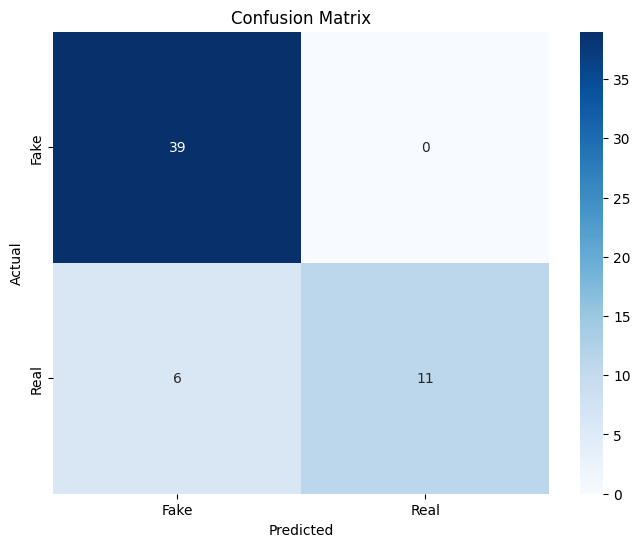

Next Step: Your model and vectorizer are saved and ready for the app!


In [19]:
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

# 1. Initialize the Model
# 'max_iter=50' means the model will go through the data 50 times to learn
pac = PassiveAggressiveClassifier(max_iter=50)

# 2. Train the Model
# We use the vectorized training data (X_train_vec) and their labels (y_train)
pac.fit(X_train_vec, y_train)

# 3. Predict on Test Data
y_pred = pac.predict(X_test_vec)

# 4. Calculate Accuracy
score = accuracy_score(y_test, y_pred)
print(f'Accuracy: {round(score*100,2)}%')

# 5. Detailed Classification Report
# This shows Precision, Recall, and F1-Score (essential for your project report)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 6. Confusion Matrix Visualization
# This shows exactly how many 'Fake' news were correctly identified
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# 7. Save the Model and Vectorizer (Necessary for your App)
# We save these as .pkl files so you don't have to retrain every time
with open('final_model.pkl', 'wb') as model_file:
    pickle.dump(pac, model_file)

with open('tfidf_vectorizer.pkl', 'wb') as vec_file:
    pickle.dump(tfidf, vec_file)

print("Next Step: Your model and vectorizer are saved and ready for the app!")

In [20]:
from sklearn.model_selection import cross_val_score
import numpy as np

# 1. Perform 5-Fold Cross Validation
# We use the whole training set (X_train_vec, y_train)
# cv=5 means the data is split into 5 chunks
scores = cross_val_score(pac, X_train_vec, y_train, cv=5)

# 2. Output the results
print(f"All Cross-Validation Scores: {scores}")
print(f"Mean Accuracy: {np.mean(scores)*100:.2f}%")
print(f"Standard Deviation: {np.std(scores)*100:.2f}%")

# Interpretation for your report:
# A low Standard Deviation (e.g., less than 1%) means your model is
# extremely stable and reliable on new, unseen data.

All Cross-Validation Scores: [0.93333333 0.88636364 0.93181818 0.90909091 0.88636364]
Mean Accuracy: 90.94%
Standard Deviation: 2.07%


In [21]:
def predict_news(news_text):
    # 1. Preprocess the input news exactly like we did for training
    cleaned_news = advanced_cleaning(news_text)

    # 2. Transform the text using our saved vectorizer
    vectorized_news = tfidf.transform([cleaned_news])

    # 3. Predict
    prediction = pac.predict(vectorized_news)

    # 4. Return result (WELFake labels: 0=Fake, 1=Real)
    return "REAL" if prediction[0] == 1 else "FAKE"

# --- TRY IT OUT ---
test_news = "BREAKING: Scientists discover life on Mars in hidden underground caves!"
print(f"Test News Result: {predict_news(test_news)}")

Test News Result: FAKE
